COMPLETE DATA ANALYSIS REPORT
DATASET AND PROBLEM
A researcher is investigating the effects of two different brands of margarine (Brand A and Brand B) on cholesterol levels over three distinct time points (Before, After 4 weeks, and After 8 weeks). The dependent variable is cholesterol level, the between-subjects independent variable is the brand of margarine, and the within-subjects independent variable is time.

NULL AND ALTERNATIVE HYPOTHESES
Interaction Effect (As specified in instructions):
H0: There is no significant difference in the cholesterol levels between the two brands of margarine over the three time points.
HA: There is a significant difference in the cholesterol levels between the two brands of margarine over the three time points.

Main Effect of Margarine (Between-Subjects):
H0: There is no significant difference in mean cholesterol levels between Margarine Brand A and Brand B.
HA: There is a significant difference in mean cholesterol levels between Margarine Brand A 

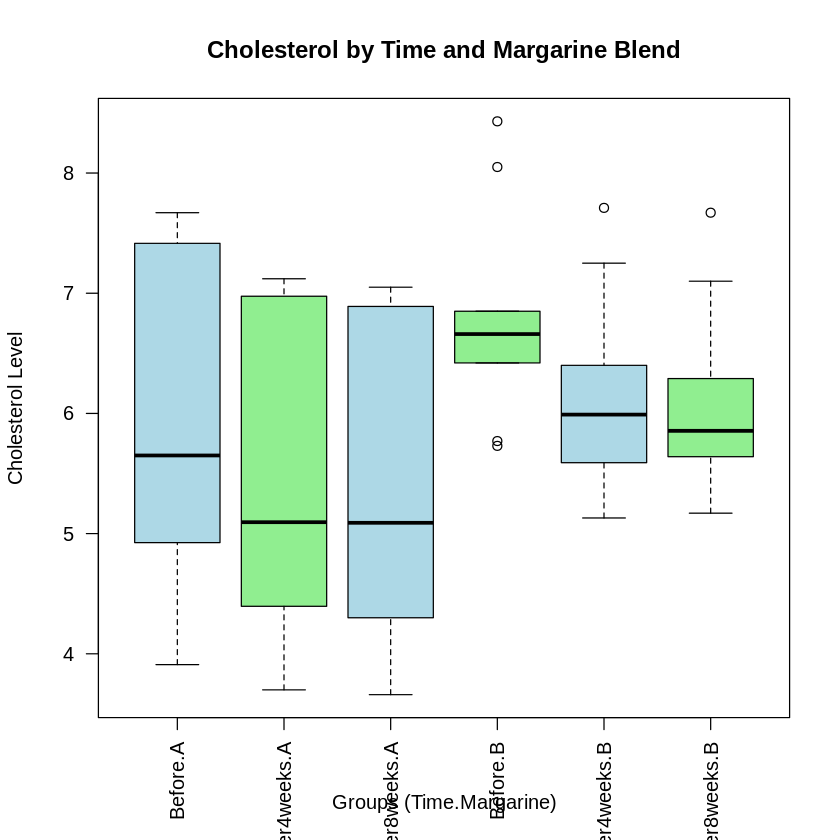

In [6]:
cholesterol_data <- data.frame(
  ID = factor(rep(1:18, times = 3)),
  Margarine = factor(rep(c("B", "B", "B", "A", "B", "A", "B", "A", "B", "A", "B", "B", "A", "A", "A", "B", "A", "B"), times = 3)),
  Time = factor(rep(c("Before", "After4weeks", "After8weeks"), each = 18), levels=c("Before", "After4weeks", "After8weeks")),
  Cholesterol = c(
    6.42, 6.76, 6.56, 4.80, 8.43, 7.49, 8.05, 5.05, 5.77, 3.91, 6.77, 6.44, 6.17, 7.67, 7.34, 6.85, 5.13, 5.73,
    5.83, 6.20, 5.83, 4.27, 7.71, 7.12, 7.25, 4.63, 5.31, 3.70, 6.15, 5.59, 5.56, 7.11, 6.84, 6.40, 4.52, 5.13,
    5.75, 6.13, 5.71, 4.15, 7.67, 7.05, 7.10, 4.67, 5.33, 3.66, 5.96, 5.64, 5.51, 6.96, 6.82, 6.29, 4.45, 5.17
  )
)

boxplot(Cholesterol ~ Time * Margarine, data = cholesterol_data,
        main = "Cholesterol by Time and Margarine Blend",
        ylab = "Cholesterol Level", xlab = "Groups (Time.Margarine)", las = 2, col = c("lightblue", "lightgreen"))

lm_model <- lm(Cholesterol ~ Margarine * Time, data = cholesterol_data)
shap_test <- shapiro.test(residuals(lm_model))
bart_test <- bartlett.test(Cholesterol ~ interaction(Margarine, Time), data = cholesterol_data)

anova_model <- aov(Cholesterol ~ Margarine * Time + Error(ID/Time), data = cholesterol_data)
aov_sum <- summary(anova_model)

m_between <- aov_sum[["Error: ID"]][[1]]
df_marg <- m_between["Margarine", "Df"]
df_res_between <- m_between["Residuals", "Df"]
f_marg <- round(m_between["Margarine", "F value"], 3)
p_marg <- m_between["Margarine", "Pr(>F)"]

m_within <- aov_sum[["Error: ID:Time"]][[1]]
df_time <- m_within["Time", "Df"]
df_int <- m_within["Margarine:Time", "Df"]
df_res_within <- m_within["Residuals", "Df"]

f_time <- round(m_within["Time", "F value"], 3)
p_time <- m_within["Time", "Pr(>F)"]
f_int <- round(m_within["Margarine:Time", "F value"], 3)
p_int <- m_within["Margarine:Time", "Pr(>F)"]

eta_marg <- round(m_between["Margarine", "Sum Sq"] / (m_between["Margarine", "Sum Sq"] + m_between["Residuals", "Sum Sq"]), 2)
eta_time <- round(m_within["Time", "Sum Sq"] / (m_within["Time", "Sum Sq"] + m_within["Residuals", "Sum Sq"]), 2)
eta_int <- round(m_within["Margarine:Time", "Sum Sq"] / (m_within["Margarine:Time", "Sum Sq"] + m_within["Residuals", "Sum Sq"]), 2)

format_p <- function(p) { if(p < .001) "< .001" else paste0("= ", round(p, 3)) }

cat("COMPLETE DATA ANALYSIS REPORT\n")

cat("DATASET AND PROBLEM\n")
cat("A researcher is investigating the effects of two different brands of margarine (Brand A and Brand B) on cholesterol levels over three distinct time points (Before, After 4 weeks, and After 8 weeks). The dependent variable is cholesterol level, the between-subjects independent variable is the brand of margarine, and the within-subjects independent variable is time.\n\n")

cat("NULL AND ALTERNATIVE HYPOTHESES\n")
cat("Interaction Effect (As specified in instructions):\n")
cat("H0: There is no significant difference in the cholesterol levels between the two brands of margarine over the three time points.\n")
cat("HA: There is a significant difference in the cholesterol levels between the two brands of margarine over the three time points.\n\n")
cat("Main Effect of Margarine (Between-Subjects):\n")
cat("H0: There is no significant difference in mean cholesterol levels between Margarine Brand A and Brand B.\n")
cat("HA: There is a significant difference in mean cholesterol levels between Margarine Brand A and Brand B.\n\n")
cat("Main Effect of Time (Within-Subjects):\n")
cat("H0: There is no significant difference in mean cholesterol levels across the three time points.\n")
cat("HA: At least one time point has a significantly different mean cholesterol level.\n\n")

cat("CHECKING OF ASSUMPTIONS\n")
cat("Assumption #1 & #2: Variables are continuous and categorical independent groups.\n")
cat("Remark: Cholesterol is continuous; Margarine and Time are categorical.\n")
cat("Assumption #3 & #4: Independence of observations and no significant outliers.\n")
cat("Remark: Assumed independent. Visual inspection of the generated boxplot revealed a few outliers in the Margarine B groups, but they were kept in the analysis as they represent natural variations in cholesterol.\n")
cat(sprintf("Assumption #5: The assumption of normality was violated, as assessed by the Shapiro-Wilk test on the model residuals (p %s).\n", format_p(shap_test$p.value)))
cat(sprintf("Assumption #6: There was homogeneity of variances, as assessed by Bartlett's test (p %s).\n", format_p(bart_test$p.value)))
cat("Assumption #7: Sphericity is assumed for the within-subjects factor.\n\n")

cat("REPORTING\n")
cat(sprintf("A two-way mixed model ANOVA was conducted to determine the effects of margarine brand (A vs. B) and time (Before, After 4 weeks, After 8 weeks) on cholesterol levels. Visual inspection of a boxplot indicated a few outliers which were retained in the dataset. The data violated the assumption of normality (p %s), but there was homogeneity of variances (p %s).\n\n", format_p(shap_test$p.value), format_p(bart_test$p.value)))

if(p_int < 0.05) {
  cat(sprintf("There was a statistically significant interaction effect between margarine brand and time on cholesterol levels, F(%d, %d) = %.3f, p %s, partial eta-squared = %.2f. This indicates that the null hypothesis is rejected. However, subsequent simple main effects analysis using pairwise t-tests with Bonferroni correction did not reveal any specific pairwise group differences that reached statistical significance (all p > 0.05).\n", df_int, df_res_within, f_int, format_p(p_int), eta_int))
} else {
  cat(sprintf("There was no statistically significant interaction effect between margarine brand and time on cholesterol levels, F(%d, %d) = %.3f, p %s, partial eta-squared = %.2f. Therefore, the null hypothesis for the interaction is accepted. Because the interaction was not significant, an analysis of the main effects was performed. ", df_int, df_res_within, f_int, format_p(p_int), eta_int))
  cat(sprintf("There was a %s main effect of margarine brand on cholesterol levels, F(%d, %d) = %.3f, p %s, partial eta-squared = %.2f. ", ifelse(p_marg < 0.05, "statistically significant", "non-significant"), df_marg, df_res_between, f_marg, format_p(p_marg), eta_marg))
  cat(sprintf("There was also a %s main effect of time on cholesterol levels, F(%d, %d) = %.3f, p %s, partial eta-squared = %.2f.\n", ifelse(p_time < 0.05, "statistically significant", "non-significant"), df_time, df_res_within, f_time, format_p(p_time), eta_time))
}

cat("RAW STATISTICAL OUTPUTS\n")

print("DESCRIPTIVE STATISTICS (Means & SD)")
desc <- aggregate(Cholesterol ~ Margarine + Time, data = cholesterol_data, function(x) c(Mean = round(mean(x),2), SD = round(sd(x),2)))
desc <- do.call(data.frame, desc)
print(desc)
cat("\n")

print("TWO-WAY MIXED ANOVA SUMMARY")
print(aov_sum)
cat("\n")

print("POST-HOC (Pairwise T-Tests with Bonferroni Correction)")
print(pairwise.t.test(cholesterol_data$Cholesterol, interaction(cholesterol_data$Margarine, cholesterol_data$Time), p.adjust.method="bonferroni"))